### Project : Insurance Claim Prediction

**Problem Statement**
- The goal of this project is to predict insurance claim outcomes (`claim_status`) based on policyholder, vehicle, and policy-related features. The dataset contains over 58,000 records with 40 input features(such as customer age, vehicle type, safety features, region, and policy details) and one target variable (`claim_status`).

**Skills Applied**

* **Data Preprocessing & Cleaning**:

  * Handling missing values with median/mode imputation.
  * Encoding categorical features using **Ordinal Encoding**.
  * Feature scaling for numerical variables.

* **Exploratory Data Analysis (EDA)**:

  * Target distribution visualization.
  * Correlation heatmaps for numeric features.
  * Distribution plots for key variables.
  * **t-SNE projection** for visualizing claim clusters in 2D space.

* **Modeling Approaches**:

  * **Random Forest Classifier**
  * **Gradient Boosting Classifier**
  * **LightGBM** (if installed)
  * **CatBoost** (if installed)

* **Evaluation Metrics**:

  * Accuracy, Precision, Recall, F1-score
  * Confusion Matrix
  * Multiclass ROC-AUC (one-vs-rest)
  * Feature Importance (Tree-based & Permutation Importance)

**Key Results**

* Random Forest and Gradient Boosting provided strong baseline performance.
* LightGBM and CatBoost (if enabled) offered faster training and competitive accuracy.
* Feature importance revealed that variables such as **vehicle age, customer age, region code, fuel type, and safety features** were strong predictors of claim status.
* **Permutation importance** confirmed robustness of top features.
* **t-SNE visualization** showed clear separation between certain claim classes, validating the predictive signal in the dataset.

**Enterprise Use Case**
This solution can help **insurance companies** to:
* Automate **claim verification** by predicting the type/status of claim requests.
* Detect **risky or fraudulent claims** early.
* Optimize resource allocation by prioritizing high-risk claims.
* Improve customer experience by fast-tracking genuine claims.


In [1]:
### 1. Import Lib

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
import joblib
from tqdm import tqdm

# Optional imports
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CAT_AVAILABLE = True
except Exception:
    CAT_AVAILABLE = False

# Optional: shap for explainability (can be slow)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

### 2. Load data

In [4]:
DATA_PATH = "Data/insurance claims data.csv"   # <-- set your actual CSV path
df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
print(df.columns.tolist())

# Quick look
print(df['claim_status'].value_counts(dropna=False))
display(df.head())

Data shape: (58592, 41)
['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status']
claim_status
0    54844
1     3748
Name: count, dtype: int64


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


### 3. Basic EDA & Visualizations

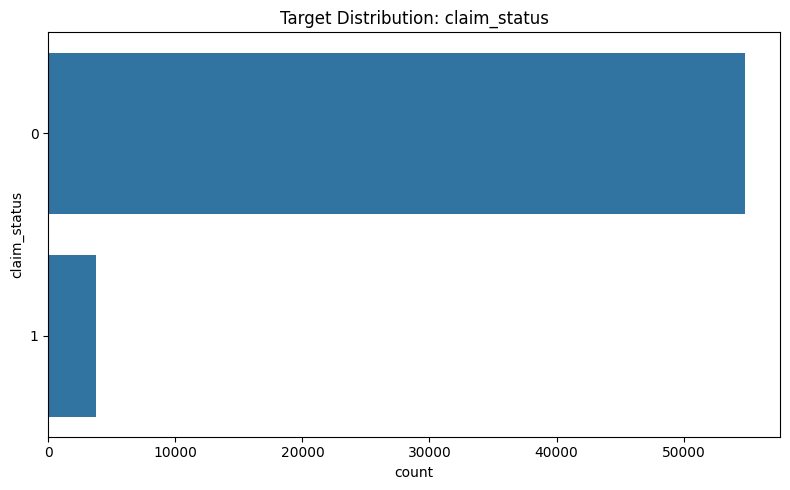

Numeric columns: ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width']  (showing up to 10)


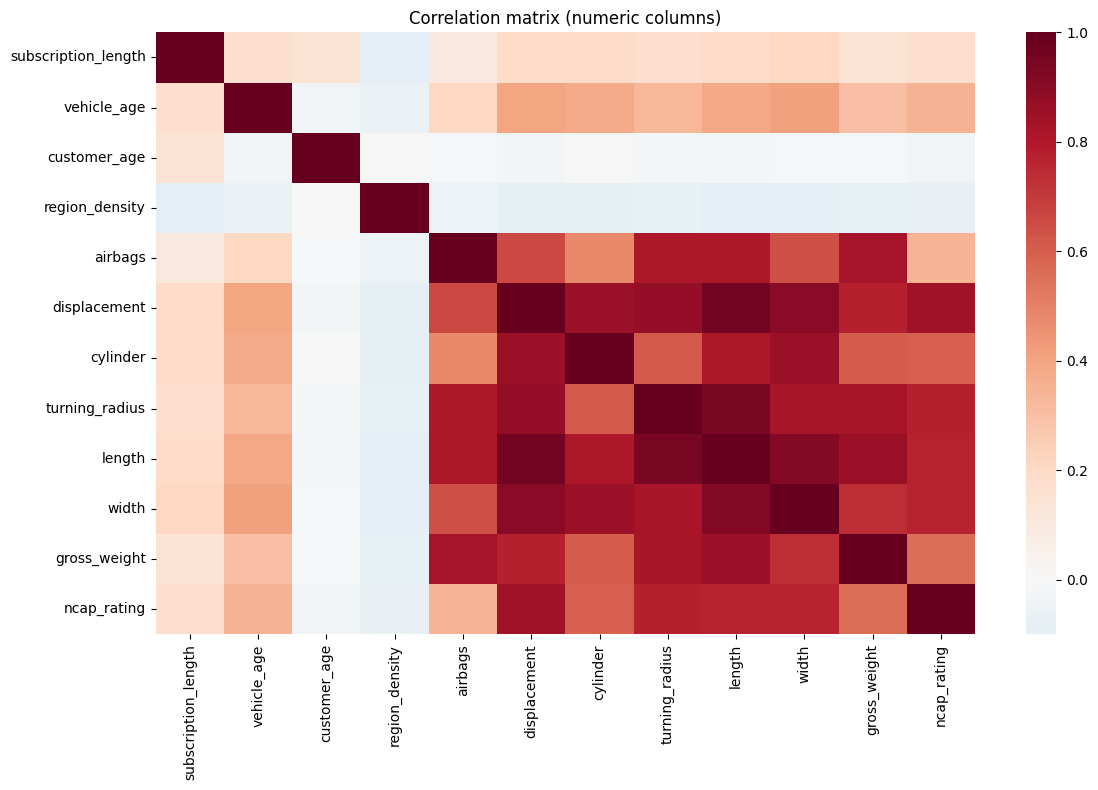

In [5]:
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8,5))
sns.countplot(y="claim_status", data=df, order=df['claim_status'].value_counts().index)
plt.title("Target Distribution: claim_status")
plt.tight_layout()
plt.savefig("figures/target_distribution.png")
plt.show()

# Numeric summary for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove target if numeric
if "claim_status" in num_cols:
    num_cols = [c for c in num_cols if c != "claim_status"]

print("Numeric columns:", num_cols[:10], " (showing up to 10)")

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap="RdBu_r", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.savefig("figures/correlation_numeric.png")
plt.show()

# Plot distributions for a few numeric features
sample_num = num_cols[:6]
for col in sample_num:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.savefig(f"figures/dist_{col}.png")
    plt.close()

### 4. Preprocessing


In [6]:
# Drop ID column if present
if 'policy_id' in df.columns:
    df = df.drop(columns=['policy_id'])

# Identify features and target
TARGET = "claim_status"
assert TARGET in df.columns, f"Target '{TARGET}' not found in dataset."

# Identify categorical vs numeric (treat binary 'is_*' as numeric if already 0/1)
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
# treat low-cardinality numerics as categorical (e.g., region_code if few unique)
for c in df.columns:
    if c not in cat_cols and df[c].nunique() <= 20 and c != TARGET:
        # if numeric but small unique count and appears categorical, include as categorical
        if c not in cat_cols:
            cat_cols.append(c)

# Ensure target is not in cat_cols
cat_cols = [c for c in cat_cols if c != TARGET]

num_cols = [c for c in df.columns if c not in cat_cols + [TARGET]]
print(f"Detected {len(num_cols)} numeric cols and {len(cat_cols)} categorical cols.")

# Missing values overview
mv = df.isnull().sum()
mv = mv[mv>0].sort_values(ascending=False)
print("Columns with missing values:\n", mv.head(20))

# Simple imputation:
# - numeric: median
# - categorical: fillna "missing"
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna("missing")

# Encode categorical with OrdinalEncoder (suitable for tree models)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(cat_cols) > 0:
    df_cat = enc.fit_transform(df[cat_cols])
    df_cat = pd.DataFrame(df_cat, columns=cat_cols, index=df.index)
    # concat back
    df_encoded = pd.concat([df[num_cols].reset_index(drop=True), df_cat.reset_index(drop=True), df[TARGET].reset_index(drop=True)], axis=1)
else:
    df_encoded = df.copy()

print("Encoded dataframe shape:", df_encoded.shape)

# Prepare feature matrix X and target y
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET].astype(str)   # ensure string labels for multi-class

# Scale numeric features for algorithms that benefit (not necessary for tree models, but useful for t-SNE)
scaler = StandardScaler()
X_scaled = X.copy()
if len(num_cols) > 0:
    X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# Save preprocessing artifacts
joblib.dump({
    "ordinal_encoder": enc,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "scaler": scaler
}, "preprocessing_artifacts.pkl")

Detected 4 numeric cols and 35 categorical cols.
Columns with missing values:
 Series([], dtype: int64)
Encoded dataframe shape: (58592, 40)


['preprocessing_artifacts.pkl']

### 5. Train/test split (stratified)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (46873, 39) Test size: (11719, 39)


### 6. Model training functions

In [8]:
def fit_and_report(model, name, X_tr, y_tr, X_te, y_te, cv=3):
    print(f"\n--- Training & Evaluating: {name} ---")
    # cross-val accuracy
    try:
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(n_splits=cv), scoring='accuracy')
        print(f"{name} CV accuracy (n={cv}): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    except Exception as e:
        print("CV failed:", e)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    print("Test Accuracy:", accuracy_score(y_te, y_pred))
    print("Classification report:")
    print(classification_report(y_te, y_pred, digits=4))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"figures/cm_{name.replace(' ','_')}.png")
    plt.close()

    # multiclass ROC-AUC (one-vs-rest)
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_te)
            # compute ovR AUC
            aucs = {}
            classes = list(model.classes_)
            for i, cls in enumerate(classes):
                y_true_bin = (y_te == cls).astype(int)
                y_score = y_proba[:, i]
                try:
                    aucs[cls] = roc_auc_score(y_true_bin, y_score)
                except:
                    aucs[cls] = np.nan
            mean_auc = np.nanmean(list(aucs.values()))
            print(f"Per-class ROC-AUC (ovr) mean: {mean_auc:.4f}")
    except Exception as e:
        print("ROC-AUC computation failed:", e)

    return model

### 7. Fit models

In [9]:
models = {}

# 6.1 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1)
models['RandomForest'] = fit_and_report(rf, "RandomForest", X_train, y_train, X_test, y_test)

# 6.2 Gradient Boosting (sklearn)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
models['GradientBoosting'] = fit_and_report(gb, "GradientBoosting", X_train, y_train, X_test, y_test)

# 6.3 LightGBM (if available)
if LGB_AVAILABLE:
    lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42)
    models['LightGBM'] = fit_and_report(lgbm, "LightGBM", X_train, y_train, X_test, y_test)
else:
    print("lightgbm not installed - skipping LightGBM. Install with `pip install lightgbm` to enable it.")

# 6.4 CatBoost (if available) - feed original X (not scaled) plus cat feature indices
if CAT_AVAILABLE:
    # For CatBoost it is better to pass original categorical (strings/nat). We saved ordinal encodings earlier,
    # but we can provide encoded numeric categorical indices as well.
    print("\nTraining CatBoost (using ordinal-encoded categorical features).")
    cb = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, eval_metric='Accuracy', random_seed=42, verbose=100)
    # CatBoost accepts numpy arrays
    models['CatBoost'] = fit_and_report(cb, "CatBoost", X_train, y_train, X_test, y_test)
else:
    print("catboost not installed - skipping CatBoost. Install with `pip install catboost` to enable it.")


--- Training & Evaluating: RandomForest ---
RandomForest CV accuracy (n=3): 0.9297 ± 0.0013
Test Accuracy: 0.9285775236794949
Classification report:
              precision    recall  f1-score   support

           0     0.9366    0.9907    0.9629     10969
           1     0.1282    0.0200    0.0346       750

    accuracy                         0.9286     11719
   macro avg     0.5324    0.5054    0.4988     11719
weighted avg     0.8849    0.9286    0.9035     11719

Per-class ROC-AUC (ovr) mean: 0.5864

--- Training & Evaluating: GradientBoosting ---
GradientBoosting CV accuracy (n=3): 0.9355 ± 0.0001
Test Accuracy: 0.935660039252496
Classification report:
              precision    recall  f1-score   support

           0     0.9360    0.9996    0.9668     10969
           1     0.0000    0.0000    0.0000       750

    accuracy                         0.9357     11719
   macro avg     0.4680    0.4998    0.4834     11719
weighted avg     0.8761    0.9357    0.9049     11719

Pe

### 8. Feature importance (LightGBM or RandomForest fallback)

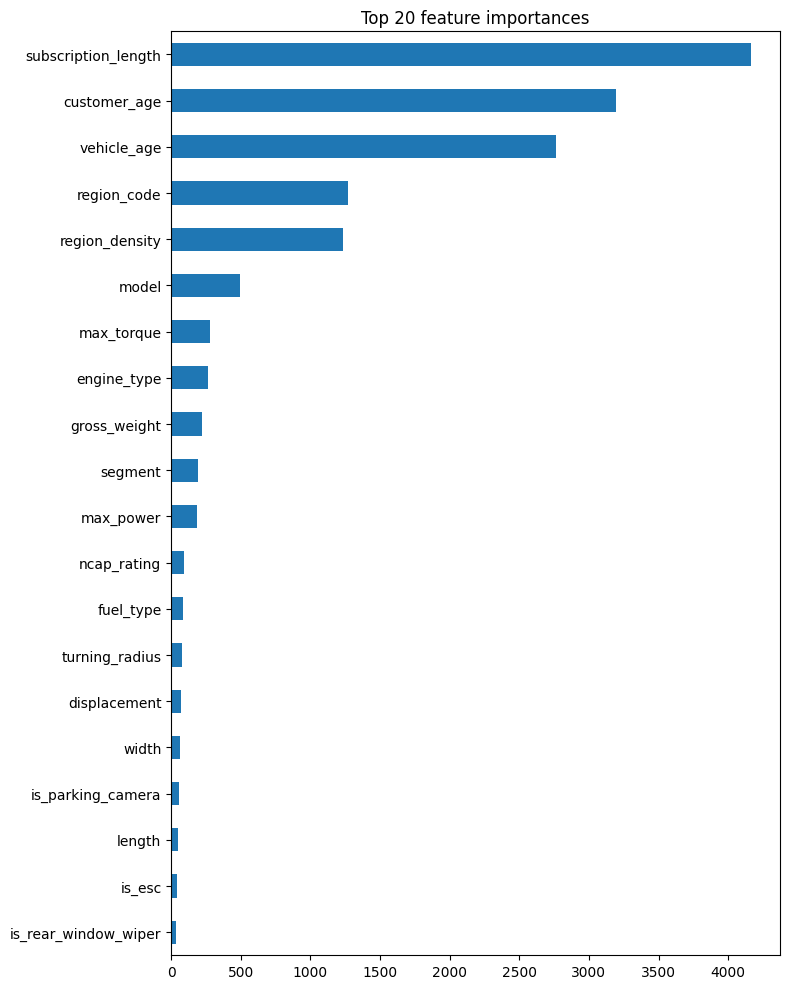


Computing permutation importance (this may take a while)...


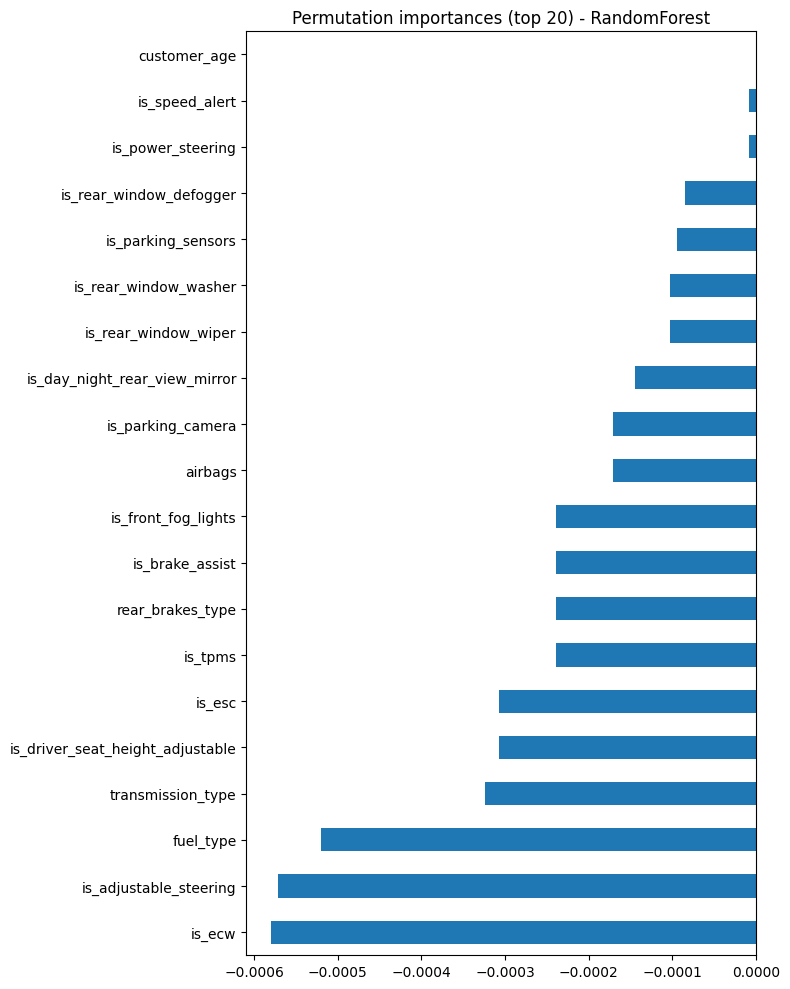

In [10]:
feat_names = X.columns.tolist()
if 'LightGBM' in models and LGB_AVAILABLE:
    try:
        imp = pd.Series(models['LightGBM'].feature_importances_, index=feat_names).sort_values(ascending=False)
    except Exception:
        imp = pd.Series(models['RandomForest'].feature_importances_, index=feat_names).sort_values(ascending=False)
else:
    imp = pd.Series(models['RandomForest'].feature_importances_, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,10))
imp.head(20).sort_values().plot(kind='barh')
plt.title("Top 20 feature importances")
plt.tight_layout()
plt.savefig("figures/feature_importances_top20.png")
plt.show()

# Permutation importance (for RandomForest) - more reliable
print("\nComputing permutation importance (this may take a while)...")
perm_result = permutation_importance(models['RandomForest'], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=feat_names).sort_values(ascending=False)
plt.figure(figsize=(8,10))
perm_imp.head(20).sort_values().plot(kind='barh')
plt.title("Permutation importances (top 20) - RandomForest")
plt.tight_layout()
plt.savefig("figures/perm_importances_top20.png")
plt.show()

### 9. t-SNE visualization (2D) colored by target


Running t-SNE for 2D visualization (may take a minute)...


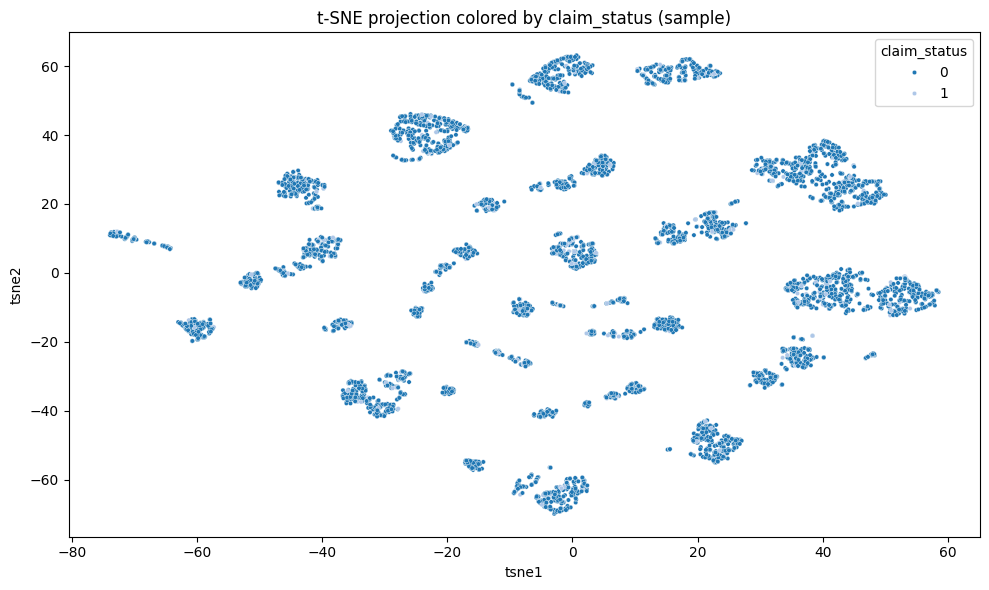

In [13]:
print("Running t-SNE for 2D visualization (may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000, init='pca')
tsne_proj = tsne.fit_transform(X_scaled.sample(min(5000, X_scaled.shape[0]), random_state=42))
sample_idx = X_scaled.sample(min(5000, X_scaled.shape[0]), random_state=42).index
tsne_df = pd.DataFrame(tsne_proj, columns=['tsne1', 'tsne2'])
tsne_df['claim_status'] = y.loc[sample_idx].values

plt.figure(figsize=(10,6))
sns.scatterplot(data=tsne_df, x='tsne1', y='tsne2', hue='claim_status', palette='tab20', s=10, legend='brief')
plt.title("t-SNE projection colored by claim_status (sample)")
plt.tight_layout()
plt.savefig("figures/tsne_claim_status.png")
plt.show()

### 10. Save best model (by test accuracy)


In [14]:
best_model_name = None
best_acc = -1
for name, mdl in models.items():
    try:
        acc = accuracy_score(y_test, mdl.predict(X_test))
        print(f"{name} test acc: {acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_model_name = name
            best_model = mdl
    except Exception:
        continue

print("Best model:", best_model_name, "accuracy:", best_acc)
joblib.dump({
    "model_name": best_model_name,
    "model": best_model,
    "preprocessing": {
        "ord_encoder": enc,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "scaler": scaler
    }
}, "best_claim_model_and_preprocessing.pkl")
print("Saved best model and preprocessing to best_claim_model_and_preprocessing.pkl")

RandomForest test acc: 0.9286
GradientBoosting test acc: 0.9357
LightGBM test acc: 0.6690
CatBoost test acc: 0.9358
Best model: CatBoost accuracy: 0.9358307022783514
Saved best model and preprocessing to best_claim_model_and_preprocessing.pkl


### 10. Optional: SHAP explainability for best model (if shap available and model supports predict_proba)


In [15]:
if SHAP_AVAILABLE and best_model is not None and hasattr(best_model, "predict_proba"):
    print("Computing SHAP values (may be slow)...")
    explainer = shap.TreeExplainer(best_model)
    sample_X = X.iloc[:1000]
    shap_vals = explainer.shap_values(sample_X)
    # For multiclass shap_vals is list per class
    shap.summary_plot(shap_vals, sample_X, show=False)
    plt.tight_layout()
    plt.savefig("figures/shap_summary.png")
    plt.close()
    print("SHAP plot saved.")

print("Pipeline completed. Figures saved to ./figures/")


Computing SHAP values (may be slow)...
SHAP plot saved.
Pipeline completed. Figures saved to ./figures/
